# Немного о многоруких бандитах

В ноутбуке про многоруких бандитов мы разбирали классы для реализации отдельных стратегий решения задачки. Реализуйте в той же парадигме, что и в ноутбуке про бандитов, стратегии [exp3](https://jamesrledoux.com/algorithms/bandit-algorithms-epsilon-ucb-exp-python/),[softmax](https://gibberblot.github.io/rl-notes/single-agent/multi-armed-bandits.html) и **successive elimination** (прочитайте о ней в книжке [Сливкинса](https://arxiv.org/abs/1904.07272)). Надо понять, как оно работает и сделать так, чтобы оно работало в использованной нами конфигурации)

В конце концов, вы ж на работе тоже нон-стоп гуглите)

## Общий класс для N-рукого бандита

In [1]:
import time
import numpy as np
from scipy.stats import beta

# Общий класс для Бернуллиевских бандитов
class BernoulliBandit():

    def __init__(self, n, probas=None):
        assert probas is None or len(probas) == n

        # Кол-во ручек
        self.n = n

        if probas is None:
            np.random.seed(int(time.time()))
            # Истинные вероятности ручек (случайно заданные)
            self.probas = [np.random.random() for _ in range(self.n)]
        else:
            # Истинные вероятности ручек, если заданы в функции
            self.probas = probas

        # Вероятность оптимальной ручки
        self.best_proba = max(self.probas)

    def generate_reward(self, i):
        # Генерация "выигрыша" для i-той ручки бандита
        if np.random.random() < self.probas[i]:
            return 1
        else:
            return 0

## Общий класс для стратегии решения задачи N-рукого бандита


In [2]:
# Класс для имплементации решения проблемы с бандитами

class Solver(object):
    def __init__(self, bandit):
        """
        bandit (Bandit): Инициализация бандита.
        """
        assert isinstance(bandit, BernoulliBandit)
        np.random.seed(int(time.time()))

        self.bandit = bandit

        self.counts = [0] * self.bandit.n
        self.actions = []  # Список id ручек от 0 до bandit.n-1.
        self.regret = 0.  # Суммарная ошибка.
        self.regrets = [0.]  # История суммарной ошибки.
        self.reward = 0. # Суммарный выигрыш.
        self.rewards = [0.] # История суммарного выигрыша.

    def update_regret(self, i):
        # i (int): Индекс выбранной ручки.
        self.regret += self.bandit.best_proba - self.bandit.probas[i]
        self.regrets.append(self.regret)

    def update_reward(self, i):
        # i (int): Индекс выбранной ручки.
#         self.reward += self.bandit.best_lambda_EV - 1/self.bandit.lambdas[i]
        self.rewards.append(self.reward)

    # Dummy-метод оценки вероятностей (переопределяется для каждого solver'a)
    @property
    def estimated_probas(self):
        raise NotImplementedError

    # Dummy-метод перехода на следующий шаг (переопределяется для каждого solver'a)
    def run_one_step(self):
        """Return the machine index to take action on."""
        raise NotImplementedError

    # Запуск работы бандита на num_steps шагов
    def run(self, num_steps):
        assert self.bandit is not None
        for _ in range(num_steps):
            i = self.run_one_step()

            self.counts[i] += 1
            self.actions.append(i)
            self.update_regret(i)
            self.update_reward(i)

## Классы для стратегий решения задачи N-рукого бандита


## Exp3

Пусть у нас есть $K$ ручек.
Каждая ручка $i$ имеет вес $w_i$ (в начале $w_i = 1$).

На каждом шаге $t$ алгоритм делает следующее:
1. Преобразуем веса в вероятности выбора:
   $$ p_i = (1 - \gamma)\frac{w_i}{\sum_{j=1}^{K} w_j} + \frac{\gamma}{K}$$

    - $\gamma \in (0, 1]$ — доля исследования (exploration rate)
    - первая часть — эксплуатация (играем больше хорошие ручки)
    - вторая часть — исследование (всё равно иногда пробуем случайные ручки, с долей γ)

2. Выбираем ручку $i$ случайно по распределению $p_i$
3. Получаем награду $r_i \in \{0, 1\}$
4. И обновляем вес выбранной ручки: $ w_i \leftarrow w_i \cdot \exp\!\left( \eta \cdot \frac{r_i}{p_i} \right)$, где $\eta > 0$ — коэффициент обучения (learning rate)

In [3]:
import math

class Exp3(Solver):
    def __init__(self, bandit, gamma=0.07, eps=1e-12):
        super().__init__(bandit)
        assert 0.0 < gamma <= 1.0
        self.K = self.bandit.n
        self.gamma = float(gamma)
        self.eta = self.gamma / self.K
        self.eps = float(eps)
        self.weights = np.ones(self.K, dtype=float)

    @property
    def estimated_probas(self):
        w = self.weights / self.weights.sum()
        return list(w)

    def run_one_step(self):
        # Вероятности выбора: смесь (эксплуатация + равномерное исследование)
        w = self.weights / self.weights.sum()
        p = (1.0 - self.gamma) * w + self.gamma / self.K

        i = np.random.choice(self.K, p=p)
        r = self.bandit.generate_reward(i)
        self.reward += r

        # Несмещённая оценка и экспоненциальное обновление веса
        p_i = max(p[i], self.eps)
        self.weights[i] *= math.exp(self.eta * (r / p_i))
        return i

## Softmax

Пусть у нас есть $K$ ручек.
1. У каждой ручки есть оценка (насколько она хороша), обозначим её как $Q_i$. В начале все $Q_i = 0$.
2. На шаге $t$ превращаем эти оценки в вероятности выбора через softmax:
$$
    p_i = \frac{e^{Q_i / \tau}}{\sum_{j=1}^{K} e^{Q_j / \tau}},
$$
	- $\tau > 0$ — это температура:
	  - при большой $\tau$ — больше случайности (исследуем)
      - при маленькой $\tau$ — выбираем почти жадно лучшую ручку
3. Затем выбираем ручку $i$ случайно по вероятностям $p_i$
4. Получаем награду $r_i \{0, 1\}$
5. Обновляем оценку для выбранной ручки $$Q_i \leftarrow Q_i + \frac{1}{N_i} (r_i - Q_i)$$ $N_i$ — количество раз, которое мы уже тянули эту ручку

In [4]:
import numpy as np
import time

class Softmax(Solver):
    def __init__(self, bandit, tau=0.1, initial_value=0.0):
        super().__init__(bandit)
        assert tau > 0.0
        self.tau = float(tau)
        self.estimates = [initial_value] * self.bandit.n  # Q_i
        self.counts = [0] * self.bandit.n                 # N_i

    @property
    def estimated_probas(self):
        # Вероятности через softmax
        exp_q = np.exp(np.array(self.estimates) / self.tau)
        return (exp_q / exp_q.sum()).tolist()

    def run_one_step(self):
        probs = self.estimated_probas
        i = np.random.choice(self.bandit.n, p=probs)
        r = self.bandit.generate_reward(i)
        self.reward += r

        # Обновляем оценку Q_i
        self.counts[i] += 1
        self.estimates[i] += (r - self.estimates[i]) / self.counts[i]
        return i


## Successive elimination

Алгоритм держит набор “живых” ручек и по ходу игры выкидывает явно слабые:
1. Для каждой ручки считаем её среднюю награду $\hat{\mu}_i(t)$ и доверительный радиус $rad_i$ — насколько мы не уверены из-за малого количества попыток.
2. Смотрим верхние и нижние оценки: $UCB_i = \hat{\mu}_i(t) + rad_i$, $LCB_i = \hat{\mu}_i(t) - rad_i$,
3. Если у какой-то ручки её верхняя граница уже меньше наилучшей нижней границы среди остальных - такую ручку удаляем: с высокой уверенностью она хуже
$$
UCB_i \;<\; \max_{j}\bigl(LCB_j),
$$
4. На каждом шаге дёргаем ручку с максимальным UCB среди ещё не удалённых

In [10]:
import math

class SuccessiveElimination(Solver):
    def __init__(self, bandit, delta=0.05, c=2.0):
        """
        delta (float): уровень уверенности в устранении (меньше -> осторожнее).
        c (float): константа в радиусе; 2.0 — разумный выбор на практике.
        """
        super().__init__(bandit)
        assert 0.0 < delta < 1.0
        assert c > 0.0
        self.delta = float(delta)
        self.c = float(c)

        K = self.bandit.n
        self.active = list(range(K))        # активные ручки
        self.estimates = [0.0] * K          # эмпирические средние \hat{mu}
        self.sums = [0.0] * K               # накопленные награды
        self._next_ptr = 0                  # указатель для round-robin по активным

    @property
    def estimated_probas(self):
        # Для удобства вернём оценки (а не вероятности)
        return list(self.estimates)

    def _radius(self, t, n_i):
        # b_i = sqrt( c * log( K * t^2 / delta ) / n_i )
        # Если ручка не игралась, радиус не считаем (обрабатываем отдельно)
        if n_i <= 0:
            return float('inf')
        K = self.bandit.n
        return math.sqrt(self.c * math.log(max(2.0, K * (t**2) / self.delta)) / n_i)

    def _eliminate(self, t):
        if len(self.active) <= 1:
            return

        # Считаем нижние и верхние доверительные границы для активных
        lowers, uppers = {}, {}
        for i in self.active:
            n_i = self.counts[i]
            b_i = self._radius(t, n_i)
            mu_i = self.estimates[i]
            lowers[i] = mu_i - b_i
            uppers[i] = mu_i + b_i

        # Опорная лучшая нижняя граница среди активных
        best_lower = max(lowers[i] for i in self.active)

        # Удаляем тех, чья верхняя граница уже ниже best_lower
        new_active = [i for i in self.active if uppers[i] >= best_lower]

        # Стабильно обновим активный список и скорректируем указатель
        if len(new_active) != len(self.active):
            self.active = new_active
            if self._next_ptr >= len(self.active):
                self._next_ptr = 0

    def run_one_step(self):
        # Если осталась одна активная — играем её
        if len(self.active) == 1:
            i = self.active[0]
        else:
            # Сначала — всем по одному испытанию
            untried = [i for i in self.active if self.counts[i] == 0]
            if len(untried) > 0:
                i = untried[0]
            else:
                # Иначе — round-robin среди активных
                i = self.active[self._next_ptr]
                self._next_ptr = (self._next_ptr + 1) % len(self.active)

        # Сыграть, получить награду
        r = self.bandit.generate_reward(i)   # r in [0,1] для Бернулли
        self.reward += r

        # Обновить статистики
        self.sums[i] += r
        self.counts[i] += 1
        self.estimates[i] = self.sums[i] / self.counts[i]

        # Элиминация по текущим границам
        t = len(self.actions) + 1  # текущий шаг (до append)
        self._eliminate(t)

        return i


# Рисовалка результатов


In [5]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def plot_results(solvers, solver_names):
    """
    Отрисовка результатов различных стратегий для бандитов.
    Args:
        solvers (list с типом Solver): Список решений проблемы бандитов, которые нужно подгонять.
        solver_names (list с типом str)
    """
    assert len(solvers) == len(solver_names)
    assert all(map(lambda s: isinstance(s, Solver), solvers))
    assert all(map(lambda s: len(s.regrets) > 0, solvers))

    b = solvers[0].bandit

    fig = plt.figure(figsize=(15, 15))

    ax1 = fig.add_subplot(221)
    ax2 = fig.add_subplot(222)
    ax3 = fig.add_subplot(223)
    ax4 = fig.add_subplot(224)

    for i, s in enumerate(solvers):
        ax4.plot(range(len(s.rewards)), s.rewards, label=solver_names[i])

    ax4.set_xlabel('Время')
    ax4.set_ylabel('Выигрыш')

    # Рисунок. 1: Зависимость ошибки от времени.
    for i, s in enumerate(solvers):
        ax1.plot(range(len(s.regrets)), s.regrets, label=solver_names[i])

    ax1.set_xlabel('Время')
    ax1.set_ylabel('Накопленная ошибка')
    ax1.legend(loc=9, bbox_to_anchor=(1.82, -0.25), ncol=5)
    ax1.grid('k', ls='--', alpha=0.3)

    # Рисунок. 2: Вероятности, оцененные алгоритмами.
    sorted_indices = sorted(range(b.n), key=lambda x: b.probas[x])
    ax2.plot(range(b.n), [b.probas[x] for x in sorted_indices], 'k--', markersize=12)
    for s in solvers:
        ax2.plot(range(b.n), [s.estimated_probas[x] for x in sorted_indices], 'x', markeredgewidth=2)
    ax2.set_xlabel('Ручки, отсортированные по ' + r'$\theta$')
    ax2.set_ylabel('Оцененная алгоритмом '+ r'$\hat\theta$')
    ax2.grid('k', ls='--', alpha=0.3)

    # Рисунок 3: Кол-во действий
    for s in solvers:
        ax3.plot(range(b.n), np.array(s.counts) / float(len(solvers[0].regrets)), ds='steps', lw=2)
    ax3.set_xlabel('Ручки')
    ax3.set_ylabel('Доля каждой ручки в общем кол-ве действий')
    ax3.grid('k', ls='--', alpha=0.3)

    plt.show()

## Функция для решения задачи о K-руком бандите за N испытаний


In [11]:
def experiment(K, N, probas = []):
    """
    Прогонка эксперимента с бернуллиевским бандитом с K руками,
    в каждой из которых случайно задается вероятность выигрыша.
    Args:
        K (int): Кол-во ручек.
        N (int): Кол-во испытаний.
        test_solvers: Список моделей решения задачи о Бандите(эпсилон-жадная, UCB и тд)
        names: Список названий стратегий для графиков
    """
    if probas == []:
        probas = list(np.round(np.random.random(K),2))
    b = BernoulliBandit(K, probas = probas)
    print("Истинные вероятности выигрыша у Бернуллиевского бандита:\n", b.probas)
    print("У лучшей ручки индекс: {} и вероятность: {}".format(
        max(range(K), key=lambda i: b.probas[i]), max(b.probas)))

    test_solvers = [
        Exp3(b),
        Softmax(b),
        SuccessiveElimination(b),
    ]
    names = [
        'Exp3',
        'Softmax',
        'SuccessiveElimination',
    ]

    for s in test_solvers:
        s.run(N)

    plot_results(test_solvers, names)

## Эксперимент


Истинные вероятности выигрыша у Бернуллиевского бандита:
 [np.float64(0.39), np.float64(0.01), np.float64(0.28), np.float64(0.19), np.float64(0.76), np.float64(0.41), np.float64(0.93), np.float64(0.03), np.float64(0.47), np.float64(0.84)]
У лучшей ручки индекс: 6 и вероятность: 0.93


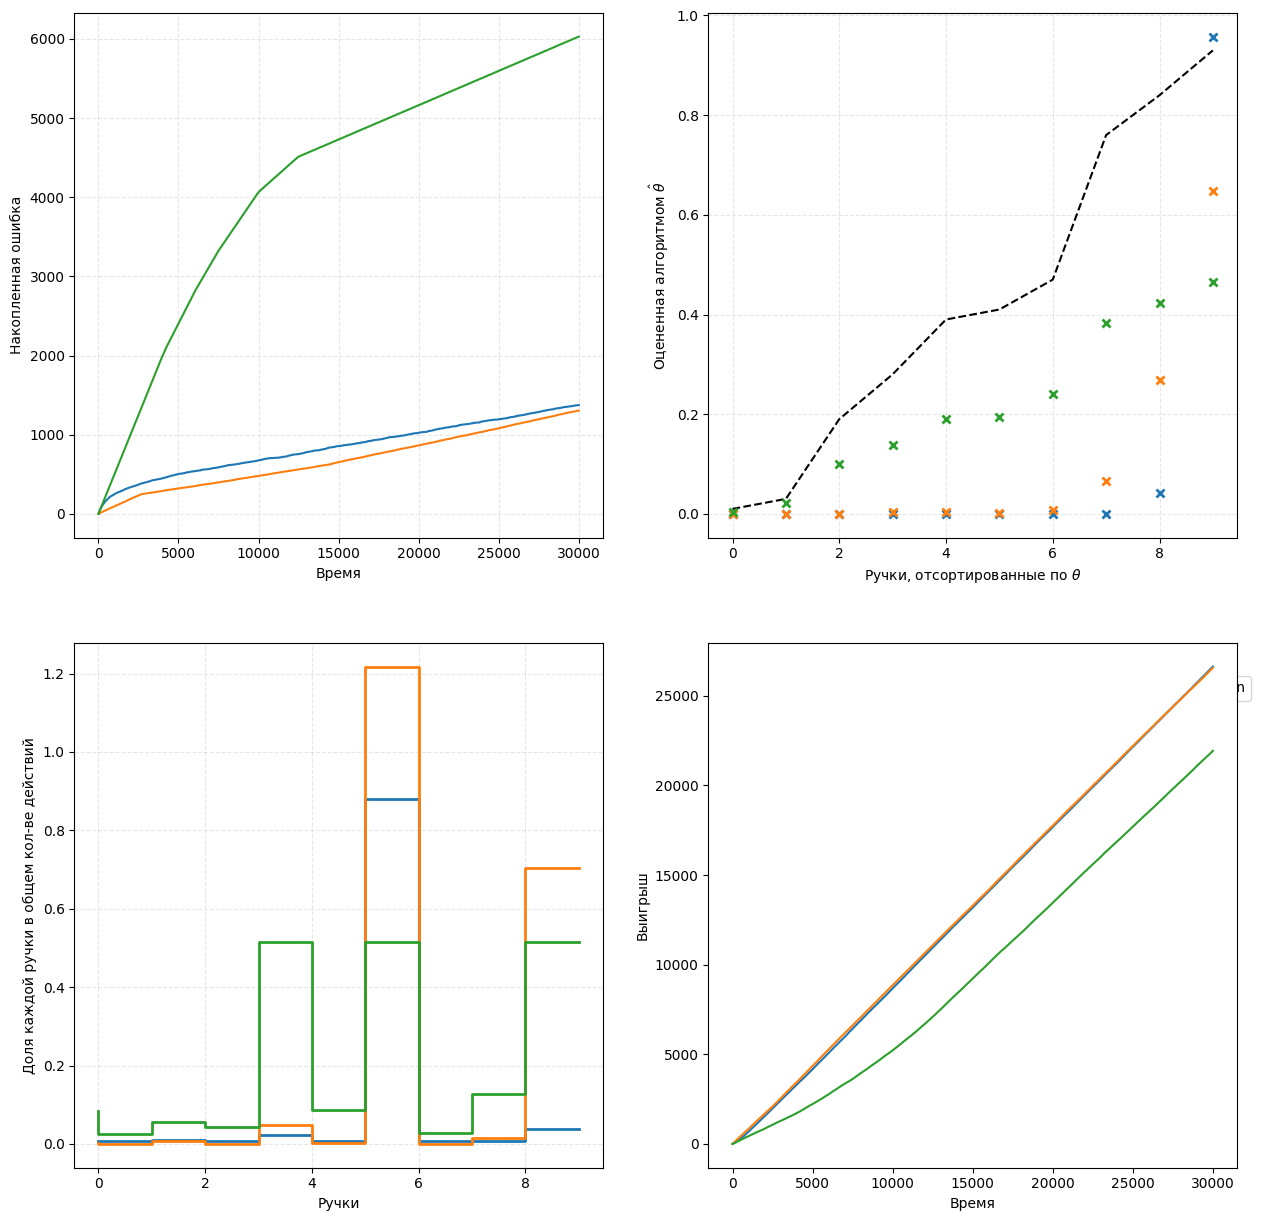

In [12]:
experiment(10, 30000)

# Еще про бандитов

У [Сливкинса](https://arxiv.org/abs/1904.07272) разберитесь с вопросом нижней границы Regret'a для любой стратегии. Тут прикладывать ничего не нужно, просто возьмите и почитайте.

# ANN

Мы разобрали LSH, IVFPQ, Annoy и HNSW

Ниже (после кода) описание задачки 


In [2]:
import time, numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss

SEED = 7
rng = np.random.default_rng(SEED)

# 1) Датасет
ds_train = load_dataset("ag_news", split="train")   # ~120k
ds_test  = load_dataset("ag_news", split="test")    # ~7.6k

X_train_text = [r["text"].strip() for r in ds_train]
y_train      = np.array([int(r["label"]) for r in ds_train], dtype=np.int64)
X_test_text  = [r["text"].strip() for r in ds_test]
y_test       = np.array([int(r["label"]) for r in ds_test], dtype=np.int64)

# 2) Эмбеддинги 
MODEL_NAME = "bert-base-nli-mean-tokens"
encoder = SentenceTransformer(MODEL_NAME)


X_db = encoder.encode(X_train_text, show_progress_bar = True)  # база (DB)
X_q  = encoder.encode(X_test_text, show_progress_bar = True)   # запросы (Q)
d = X_db.shape[1]

print("DB:", X_db.shape, "Q:", X_q.shape, "dim:", d)

# 3) (опц.) делаем дисбаланс в БАЗЕ для класса-«хвоста»
RARE_CLASS = 3
keep_ratio = 0.15  # оставим ~15% редкого класса в базе
idx_rare = np.where(y_train == RARE_CLASS)[0]
idx_keep_rare = rng.choice(idx_rare, size=max(1,int(len(idx_rare)*keep_ratio)), replace=False)
idx_nonrare = np.where(y_train != RARE_CLASS)[0]
idx_final = np.sort(np.concatenate([idx_nonrare, idx_keep_rare]))
X_db = X_db[idx_final]; y_db = y_train[idx_final]
print(f"DB after imbalance: {len(X_db)}; rare count={np.sum(y_db==RARE_CLASS)}")

# 4) Эталонный точный индекс (FlatIP) и топ-k для всех запросов
K = 50
flat = faiss.IndexFlatIP(d)
flat.add(X_db)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3750 [00:00<?, ?it/s]

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

DB: (120000, 768) Q: (7600, 768) dim: 768
DB after imbalance: 94500; rare count=4500


## Про "потерю информации" от ANN

Для HNSW, IVFPQ и Annoy (LSH не обязательно, но можно) оценить:
 

### 1) Структурные потери ANN

Оцениваем, насколько набор соседей из ANN совпадает с обычным kNN:
$$
\operatorname{Recall@k}^{\text{w.r.t. exact}} ;=; \frac{|A_k \cap E_k|}{k},
$$

где $(E_k)$ — точные top-(k) соседи, $(A_k)$ — top-(k) из ANN.
Чем ниже значение, тем больше потеря структуры соседства.

### 2) Потери информации о метках (классах)

Предсказываем метку по **голосованию** среди соседей и сравниваем с эталоном:
$$
\Delta \mathrm{Acc@k} = \mathrm{Acc}\big(\hat y^{\text{ANN}}*{k}\big)-\mathrm{Acc}\big(\hat y^{\text{Exact}}*{k}\big),
$$
где $(\hat y_k)$ — метка, выбранная по большинству среди top-(k) соседей.


### 3) Неоднородность распределения классов среди соседей

Для каждого запроса считаем частоты классов среди соседей: $(p^{\text{Exact}}*{k})$ и $(p^{\text{ANN}}*{k})$.

В качестве меры неоднородности распределения классов можете использовать, что вам заблагорассудится: можете энтропию, можете Джини, а можете еще что-то :)


### 4) Потери по «хвосту» (редкий класс)

Выбираем «редкий» класс и искусственно уменьшаем его долю в базе.
Считаем Rare-Recall@k как долю запросов редкого класса, у которых **есть хотя бы один** сосед того же класса в top-(k).
Затем смотрим разницу относительно эталона – Flat-индекса:
$$
\Delta \mathrm{Rare\text{-}Recall@k} = \mathrm{Rare\text{-}Recall@k}^{\text{ANN}} - \mathrm{Rare\text{-}Recall@k}^{\text{Exact}}.
$$

### 5) Потеря  близости

Сравниваем среднюю косинусную близость (или скалярное произведение) соседей у эталона и ANN:

$$
\Delta \overline{s} = \overline{\langle q, x_{kNN}\rangle}-\overline{\langle q, x_{ANN}\rangle}.
$$


Положительное $(\Delta \overline{s})$ означает падение средней близости у ANN относительно эталона.



### Какой ANN лучше?

Какой из ANN-индексов на ваш взгляд получился лучше? Почему?



